# III. Prescriptive / Multivariate Analysis

## Hospitalized Patients with Heart Failure

### Objective

The Descriptive Analysis established the baseline characteristics, clinical severity, comorbidity burden, laboratory patterns, treatment patterns, hospitalization outcomes, and readmission/mortality rates in the cohort.

The Prescriptive / Multivariate Analysis builds on those findings by investigating relationships between multiple clinical, demographic, treatment, and outcome variables.

The objective is to identify:

- factors associated with clinical severity and outcomes,
- combinations of factors that identify different patient profiles,
- relationships between clinical condition and hospitalization/resource use,
- factors that provide information beyond individual severity measures,
- and evidence-supported candidate features for the Predictive Analysis.

Rather than analyzing variables independently, this stage focuses on clinically meaningful relationships and combinations of variables.

### Analytical Flow

Descriptive Findings
        ↓
Identify Important Patterns
        ↓
Formulate Analytical Questions
        ↓
Test Relationships and Interactions
        ↓
Identify Meaningful Patient Profiles
        ↓
Evaluate Incremental Information
        ↓
Select Evidence-Supported Candidate Predictors
        ↓
Predictive Analysis

## 1. Import Libraries
The Prescriptive Analysis requires statistical comparisons, association testing, subgroup analysis, and visualization.
We will use a focused set of Python libraries rather than importing unnecessary packages.


In [4]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
from scipy.stats import chi2_contingency

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Cleaned Master Patient Dataset
The data-cleaning stage has already produced the patient-level analytical dataset.

The Prescriptive Analysis should use the cleaned master dataset so that all questions are based on the same patient population and the same previously validated definitions.

#### What will we do?
Load the finalized `patient_master.csv` created during the Data Cleaning stage.

A single patient-level dataset containing the clinical, demographic, hospitalization, outcome, and treatment information required for the Prescriptive Analysis.

In [5]:
from pathlib import Path

# Try the team's original path first, then common locations near this notebook.
DATA_PATH = Path(
    r"C:\Users\arjai\Documents\Shraddha Job Search\Data Science\Python\Hackathon Sept 2026\Python_Hackathon_Sep_2026"
)
candidates = [DATA_PATH / "cleaned_data" / "patient_master.csv"]
for base in [Path.cwd(), *Path.cwd().parents]:
    candidates += [base / "cleaned_data" / "patient_master.csv",
                   base / "patient_master.csv"]

MASTER_PATH = next((p for p in candidates if p.is_file()), None)
if MASTER_PATH is None:
    raise FileNotFoundError(
        "Could not find patient_master.csv. Run the final cleaning notebook, "
        "then put the CSV in cleaned_data/ beside this notebook."
    )
CLEANED_PATH = MASTER_PATH.parent
df = pd.read_csv(MASTER_PATH)
print("Master dataset loaded:", MASTER_PATH)
print(f"Rows: {len(df):,}; columns: {df.shape[1]:,}")

Master dataset loaded successfully.
Rows: 2,008
Columns: 198


## 3. Analytical Dataset Validation

Before beginning multivariate analysis, we need to confirm that the analytical dataset has the expected patient-level structure.
This prevents accidental use of duplicate records, incorrect joins, or unexpected changes to the cleaned dataset.

- Number of patients
- Unique patient identifiers
- Duplicate patient records
- Availability of key variables
- Data types of variables used in Category 3

Confirm that the Prescriptive Analysis is based on the same 2,008-patient master cohort established during data cleaning.

In [3]:
# Verify patient-level structure and names from the final cleaning notebook.
print("Dataset shape:", df.shape)
print("Unique patients:", df["inpatient_number"].nunique())
print("Duplicate patient IDs:", df["inpatient_number"].duplicated().sum())
key_variables = [
    "inpatient_number", "glomerular_filtration_rate", "cci_score",
    "nyha_cardiac_function_classification", "killip_grade",
    "brain_natriuretic_peptide", "dischargeday",
    "re_admission_within_6_months", "death_within_6_months",
    "age_category", "diabetes", "moderate_to_severe_chronic_kidney_disease"
]
available = [name for name in key_variables if name in df.columns]
missing = [name for name in key_variables if name not in df.columns]
print("Available:", available)
print("Missing:", missing)
if missing or df["inpatient_number"].duplicated().any():
    raise ValueError("The master CSV does not match the final cleaned patient dataset.")

Dataset shape: (2008, 198)

Unique patients:
2008

Duplicate patient IDs:
0

Key variables available:
Available: ['inpatient_number', 'glomerular_filtration_rate', 'brain_natriuretic_peptide']
Missing: ['CCI_score', 'NYHA', 'Killip', 'dischargeDay']


### 4. Transition from Descriptive to Prescriptive / Multivariate Analysis

The Descriptive Analysis established several important characteristics of the cohort.

Key observations included:

- A substantial proportion of patients had reduced renal function based on measured GFR.
- The prevalence of the CKD indicator was lower than the proportion with measured GFR <60 mL/min/1.73 m².
- Admission severity was characterized using NYHA and Killip classifications.
- BNP showed a strongly right-skewed distribution and varied across NYHA severity groups.
- Comorbidity burden was present across the cohort, with CKD and diabetes among the more prevalent conditions.
- Six-month readmission occurred considerably more frequently than six-month mortality.
- Length of stay varied across patients, and exploratory analysis showed an association between medication burden and length of stay.

These findings generate questions that cannot be answered by descriptive statistics alone.

The Prescriptive / Multivariate Analysis therefore moves from:

**"What do we observe?"**

to: **"How are these factors related, do they provide additional information when considered together, and which combinations identify meaningful patient profiles?"**

## Section 1 — Renal Function & Admission Severity

### Q1. Does the CKD flag identify the same renal-risk population as measured GFR <60 mL/min/1.73m²?

**Why:** Descriptive analysis flagged a gap between the coded CKD comorbidity indicator and the share of patients with measured GFR<60. The data dictionary defines that exact indicator using the same <60 cutoff, so the two should largely agree — testing whether they actually do determines which one we trust as the primary renal-risk variable for every downstream question in this section.

**What We Expect:** Given the shared cutoff, we expect substantial but not perfect overlap — some disagreement is plausible if the CKD flag reflects a historical diagnosis while GFR reflects current lab values, but a large gap would suggest the flag under-captures current renal risk.

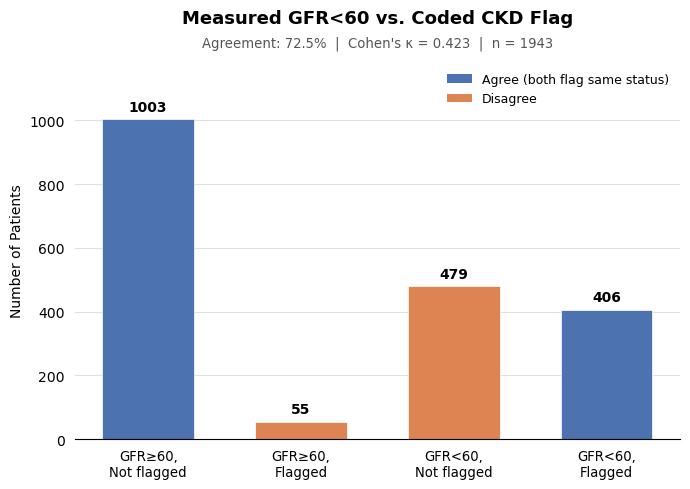

In [7]:
# Recreate the contingency table so the starter Q1 chart works when run from the top.
q1 = df[["glomerular_filtration_rate", "moderate_to_severe_chronic_kidney_disease"]].copy()
q1["glomerular_filtration_rate"] = pd.to_numeric(q1["glomerular_filtration_rate"], errors="coerce")
q1["moderate_to_severe_chronic_kidney_disease"] = pd.to_numeric(
    q1["moderate_to_severe_chronic_kidney_disease"], errors="coerce"
)
q1 = q1.dropna()
q1 = q1[q1["moderate_to_severe_chronic_kidney_disease"].isin([0, 1])]
q1["low_gfr"] = (q1["glomerular_filtration_rate"] < 60).astype(int)
ct = pd.crosstab(q1["low_gfr"], q1["moderate_to_severe_chronic_kidney_disease"])
ct = ct.reindex(index=[0, 1], columns=[0, 1], fill_value=0)
n = int(ct.to_numpy().sum())
if n == 0:
    raise ValueError("No usable GFR and CKD flag pairs for the Q1 chart.")
po = (ct.loc[0, 0] + ct.loc[1, 1]) / n
row_share = ct.sum(axis=1) / n
col_share = ct.sum(axis=0) / n
pe = row_share.loc[0] * col_share.loc[0] + row_share.loc[1] * col_share.loc[1]
kappa = (po - pe) / (1 - pe) if pe < 1 else float("nan")
display(ct.rename(index={0: "GFR >=60", 1: "GFR <60"},
                  columns={0: "CKD not flagged", 1: "CKD flagged"}))

# Visualization — cleaner version
fig, ax = plt.subplots(figsize=(7, 5))

labels = ["GFR≥60,\nNot flagged", "GFR≥60,\nFlagged", "GFR<60,\nNot flagged", "GFR<60,\nFlagged"]
values = [ct.loc[0,0], ct.loc[0,1], ct.loc[1,0], ct.loc[1,1]]

agree_color = "#4C72B0"     # the two cells where GFR and flag agree
disagree_color = "#DD8452"  # the two cells where they disagree
colors = [agree_color, disagree_color, disagree_color, agree_color]

bars = ax.bar(labels, values, color=colors, width=0.6, edgecolor="white", linewidth=0.5)

# Labels above bars, with enough headroom so nothing touches the top
ax.bar_label(bars, padding=4, fontsize=10, fontweight="bold")
ax.set_ylim(0, max(values) * 1.18)

# Clean up the frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.yaxis.grid(True, color="#e0e0e0", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(left=False, bottom=False)

ax.set_ylabel("Number of Patients", fontsize=10)
ax.set_title("Measured GFR<60 vs. Coded CKD Flag", fontsize=13, fontweight="bold", pad=28)
ax.text(0.5, 1.04, f"Agreement: {po*100:.1f}%  |  Cohen's κ = {kappa:.3f}  |  n = {n}",
        transform=ax.transAxes, ha="center", fontsize=9.5, color="#555555")

plt.xticks(fontsize=9.5)

# Legend explaining the color coding
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=agree_color, label="Agree (both flag same status)"),
    Patch(facecolor=disagree_color, label="Disagree"),
]
ax.legend(handles=legend_handles, loc="upper right", frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

**Finding**

885/1,943 (45.55%) have GFR<60; only 461 (23.73%) carry the CKD flag. 479 patients (24.7%) are low-GFR but unflagged; only 55 (2.8%) are flagged with normal GFR. Agreement = 72.5%, but Cohen's κ = 0.423 (moderate, not strong). Chi-square p ≈ 2.46e-97 — significant, but with n=1,943 that reflects sample size, not interchangeability.

**Observation & Implication**

The two measures disagree more than they agree meaningfully (κ=0.423), and the flag under-catches far more than it over-flags. Measured GFR will be used as the primary renal-function variable going forward; the CKD flag stays separate as a comorbidity variable, not a GFR proxy. Sets up Q2 (GFR vs. severity) using the lab value.

**Counter-Argument:** CKD is a chronic diagnosis — some "missed" patients may just have a normal GFR at this admission despite a history of impairment. Doesn't change the choice: current GFR is still the right variable for a cross-sectional analysis.

## Family 3 — Cardiac Biomarker and Renal Function (Questions 11–13)

These analyses use the final `patient_master.csv`. Each question builds a *new*
working table, so it can be run without variables created by another family's
question. Percentages always use patients with a recorded outcome and marker;
a missing biomarker or outcome never counts as a negative result. Results show
associations in these patients, not treatment effects or confirmed clinical risk scores.

In [ ]:
# Step 1: Set exact column names produced by the team's cleaning notebook.
OUTCOME = "re_admission_within_6_months"
DEATH = "death_within_6_months"
BNP = "brain_natriuretic_peptide"
GFR = "glomerular_filtration_rate"
NYHA = "nyha_cardiac_function_classification"
KILLIP = "killip_grade"
CCI = "cci_score"
CKD = "moderate_to_severe_chronic_kidney_disease"

# Step 2: Report counts and observed rates using the correct group denominators.
# Missing outcomes are excluded BEFORE this function is called.
def outcome_rates(frame, groups, outcome):
    result = (frame.groupby(groups, observed=True, dropna=False)[outcome]
              .agg(n="size", events="sum"))
    result["rate_pct"] = (100 * result["events"] / result["n"]).round(1)
    return result

# Step 3: Make a complete-case working copy without changing the master df.
# The cleaning notebook marked a small number of contradictory event records;
# exclude them from analyses of the 6-month readmission label when the flag exists.
def analysis_rows(columns, outcome=OUTCOME):
    cols = list(dict.fromkeys([*columns, outcome]))
    if "event_time_contradiction_flag" in df.columns and outcome == OUTCOME:
        cols.append("event_time_contradiction_flag")
    if "outcome_destination_flag" in df.columns and outcome == DEATH:
        cols.append("outcome_destination_flag")
    work = df[cols].copy()
    if "event_time_contradiction_flag" in work:
        work = work.loc[~work["event_time_contradiction_flag"].astype(str)
                        .str.strip().str.lower().isin(["true", "1"])].drop(columns="event_time_contradiction_flag")
    if "outcome_destination_flag" in work:
        work = work.loc[~work["outcome_destination_flag"].astype(str)
                        .str.strip().str.lower().isin(["true", "1"])].drop(columns="outcome_destination_flag")
    for name in cols:
        if name in work and name != "age_category":
            work[name] = pd.to_numeric(work[name], errors="coerce")
    work = work.dropna(subset=list(dict.fromkeys([*columns, outcome])))
    work = work.loc[work[outcome].isin([0, 1])].copy()
    print(f"Usable patients: {len(work):,} of {len(df):,}; {outcome} events: {int(work[outcome].sum()):,}")
    return work

# Step 4: Use the SAME complete cases for each pair of nested logistic models.
# A likelihood-ratio test asks whether the added columns explain outcome
# variation beyond the smaller model; neither model establishes causality.
from scipy.optimize import minimize
def nested_logistic_test(y, base, added):
    y = np.asarray(y, dtype=float)
    base = np.asarray(base, dtype=float).reshape(len(y), -1)
    added = np.asarray(added, dtype=float).reshape(len(y), -1)
    if len(np.unique(y)) < 2:
        print("Both outcome classes are needed; interaction test not estimable.")
        return np.nan, np.nan
    def fit(x):
        x = np.column_stack([np.ones(len(y)), x])
        result = minimize(lambda beta: np.logaddexp(0, x @ beta).sum()
                          - y @ (x @ beta), np.zeros(x.shape[1]), method="L-BFGS-B")
        if not result.success:
            print("Model optimization warning:", result.message)
        return -float(result.fun)
    lr = max(0.0, 2 * (fit(np.column_stack([base, added])) - fit(base)))
    p = stats.chi2.sf(lr, added.shape[1])
    return lr, p

# Severity rule shared by Q13 and Q18. This is an exploratory grouping,
# explicitly defined here so the result cannot be changed after seeing it.
def severe_presentation(frame):
    return (frame[NYHA] >= 4) | (frame[KILLIP] >= 3)

# Anchor subgroup percentages to the overall rates the descriptive
# notebook reported. Subsequent analyses may exclude flagged/missing rows.
for target in [OUTCOME, DEATH]:
    known = pd.to_numeric(df[target], errors="coerce")
    known = known[known.isin([0, 1])]
    print(f"Full-cohort {target}: {int(known.sum())}/{len(known)} = {known.mean():.1%}")
print("Shared helpers ready; master dataframe left unchanged.")

### Q11. Is higher BNP associated with higher six-month readmission?

**Why:** BNP is a heart-failure biomarker. Comparing *readmission rates* across
BNP levels tests whether patients with higher recorded BNP have different
follow-up outcomes. Quartiles are derived from nonmissing BNP values in this
dataset, so they are data groupings rather than clinical cutoffs.

**How:** Remove missing/invalid BNP and missing outcomes; report group size,
readmissions, and within-group rates. Use a chi-square comparison and a
patient-level rank trend as supporting evidence. Also print the BNP boundaries.

In [ ]:
# Step 1: Keep patients with nonmissing BNP and a known binary outcome.
q11 = analysis_rows([BNP])
q11 = q11.loc[q11[BNP] >= 0].copy()
print("Nonnegative BNP measurements:", len(q11))

# Step 2: Rank BNP, then make four roughly equal-sized groups. Ranking
# avoids qcut's duplicate-edge error if several patients have the same BNP.
q11["BNP_quartile"] = pd.qcut(q11[BNP].rank(method="first"), 4,
                              labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])
print("BNP by group (min / median / max):")
display(q11.groupby("BNP_quartile", observed=True)[BNP].agg(["min", "median", "max"]))
q11_rates = outcome_rates(q11, "BNP_quartile", OUTCOME)
display(q11_rates)

# Step 3: Compare observed rates and test whether their distribution differs.
cont = pd.crosstab(q11["BNP_quartile"], q11[OUTCOME])
chi2, p, _, expected = chi2_contingency(cont)
rank_r, trend_p = stats.spearmanr(q11["BNP_quartile"].cat.codes, q11[OUTCOME])
print(f"Chi-square p={p:.4g}; rank association r={rank_r:.3f}, p={trend_p:.4g}")
if (expected < 5).any():
    print("Some expected cell counts are below 5; interpret chi-square cautiously.")

# Step 4: Plot percentages AND show the patient counts on each bar.
ax = q11_rates["rate_pct"].plot.bar(figsize=(8, 4), color="#4169a2", rot=0)
ax.set(ylabel="Six-month readmission (%)", xlabel="BNP group",
       title="Six-month readmission across BNP quartiles")
for bar, count in zip(ax.patches, q11_rates["n"]):
    ax.annotate(f"n={count}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.ylim(0, max(5, q11_rates["rate_pct"].max() * 1.22))
plt.tight_layout(); plt.show()
print("Interpretation: compare Q4 with Q1 using the displayed rates and group sizes;")
print("a p-value or rising pattern alone does not show BNP causes readmission.")

### Q12. Does BNP add information about six-month readmission beyond NYHA and Killip?

**Why:** BNP could reflect information already captured by severity grades.
Test whether adding it to the two severity measures improves separation of
readmitted versus non-readmitted patients *on the same complete-case sample*.

**How:** Compare severity-only and severity-plus-BNP logistic models with
five-fold cross-validated ROC AUC. The likelihood-ratio test offers a separate
measure of association after accounting for NYHA and Killip. This is exploratory
analysis, not a validated clinical prediction model.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, brier_score_loss

# Step 1: Same complete patients and outcomes for BOTH model comparisons.
q12 = analysis_rows([NYHA, KILLIP, BNP])
q12 = q12.loc[q12[BNP] >= 0].copy()
q12["log_BNP"] = np.log1p(q12[BNP])  # Compress the right-skewed BNP distribution.
baseline = q12[[NYHA, KILLIP]].to_numpy()
expanded = q12[[NYHA, KILLIP, "log_BNP"]].to_numpy()
y12 = q12[OUTCOME].astype(int).to_numpy()

# Step 2: Split data into the same stratified folds for both models.
folds = min(5, np.bincount(y12).min())
if folds < 2:
    raise ValueError("Not enough outcomes in both classes for Q12 validation.")
cv12 = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
results12 = {}
for name, x in [("NYHA + Killip", baseline), ("NYHA + Killip + BNP", expanded)]:
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    probabilities = cross_val_predict(model, x, y12, cv=cv12, method="predict_proba")[:, 1]
    results12[name] = [roc_auc_score(y12, probabilities),
                       brier_score_loss(y12, probabilities)]
comparison12 = pd.DataFrame(results12, index=["CV ROC AUC (higher better)",
                                             "CV Brier score (lower better)"]).T
display(comparison12.round(3))

# Step 3: Test whether BNP is associated with the outcome after accounting
# for the two severity grades on these same patients.
lr12, p12 = nested_logistic_test(y12, baseline, q12[["log_BNP"]])
print(f"BNP added to NYHA + Killip: likelihood-ratio statistic={lr12:.2f}, p={p12:.4g}")
print("Interpretation: compare BOTH AUC and Brier scores. A small/negative")
print("change in held-out performance would not support a useful added signal.")

### Q13. Does the combination of admission severity, BNP and renal function identify a different readmission subgroup?

**Why:** These measures represent different clinical domains. We examine whether
patients with none, one, two, or all three recorded signals show different
observed outcomes, while checking the number of patients in every subgroup.

**Group rules:** severe presentation = NYHA 4 **or** Killip 3–4;
higher BNP = at or above the *complete-case cohort median*; low GFR = <60.
These are exploratory categories, not clinical recommendations.

In [ ]:
# Step 1: Restrict to patients who have all three markers AND outcome recorded.
q13 = analysis_rows([NYHA, KILLIP, BNP, GFR])
q13 = q13.loc[(q13[BNP] >= 0) & (q13[GFR] > 0)].copy()
median_bnp13 = q13[BNP].median()
q13["severe"] = severe_presentation(q13).astype(int)
q13["high_BNP"] = (q13[BNP] >= median_bnp13).astype(int)
q13["low_GFR"] = (q13[GFR] < 60).astype(int)
q13["signals"] = q13[["severe", "high_BNP", "low_GFR"]].sum(axis=1)
print(f"Exploratory high-BNP boundary: >= {median_bnp13:.2f} (dataset median)")

# Step 2: Compare rates with their denominators; 0 vs 3 is useful only if
# both groups have enough observations to interpret.
rates13 = outcome_rates(q13, "signals", OUTCOME).reindex([0, 1, 2, 3], fill_value=0)
display(rates13)
print("Every combination (S=severe, B=higher BNP, R=low GFR):")
profiles13 = outcome_rates(q13, ["severe", "high_BNP", "low_GFR"], OUTCOME)
display(profiles13)
if (profiles13["n"] < 20).any():
    print("CAUTION: one or more profiles have fewer than 20 patients.")

# Association test for the prespecified 0–3 signal count. A rate gradient
# supports an association only if the sample sizes and trend also support it.
rho13, p13 = stats.spearmanr(q13["signals"], q13[OUTCOME])
print(f"Signal-count/readmission rank association: r={rho13:.3f}, p={p13:.4g}")

# Step 3: Visualize observed rates; show n above each bar to avoid hiding
# an unstable high percentage in a small subgroup.
ax = rates13["rate_pct"].plot.bar(figsize=(7, 4), rot=0, color="#6c8fa8")
ax.set(xlabel="Number of signals present (0–3)",
       ylabel="Six-month readmission (%)", title="Observed readmission by combined profile")
for bar, count in zip(ax.patches, rates13["n"]):
    ax.annotate(f"n={count}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.ylim(0, max(5, rates13["rate_pct"].max()*1.2))
plt.tight_layout(); plt.show()
print("Interpretation: report both the 0-vs-3 rate difference and the sample")
print("sizes; these categories must not be treated as a validated score.")

## Family 4 — Comorbidity and Demographic Risk (Questions 14–18)

We use the recorded Charlson comorbidity index (`cci_score`), recorded
diagnosis flags, and age *categories* from the cleaning notebook. The age
file has bands, not each patient's exact age. Most questions use six-month
readmission; Q15 uses the separate, rarer six-month death indicator.

### Q14. Is higher CCI associated with higher six-month readmission?

**Why:** A higher CCI summarizes more recorded comorbidity burden. Groups
0–1, 2 and 3+ preserve a usable size in each category; they do not imply
that the score itself changes the patient's outcome.

In [ ]:
# Step 1: Keep a known CCI and known readmission outcome.
q14 = analysis_rows([CCI])
q14 = q14.loc[q14[CCI] >= 0].copy()
q14["CCI_group"] = pd.cut(q14[CCI], [-0.1, 1, 2, np.inf],
                          labels=["0–1", "2", "3+"])

# Step 2: Calculate within-group readmission rates and event counts.
rates14 = outcome_rates(q14, "CCI_group", OUTCOME)
display(rates14)
table14 = pd.crosstab(q14["CCI_group"], q14[OUTCOME])
chi2_14, p14, _, expected14 = chi2_contingency(table14)
rho14, trend14 = stats.spearmanr(q14[CCI], q14[OUTCOME])
print(f"Group comparison p={p14:.4g}; CCI rank association r={rho14:.3f}, p={trend14:.4g}")
if (expected14 < 5).any():
    print("Small expected counts: chi-square p-value may be unreliable.")

# Step 3: Show both denominators and rates; report what the actual pattern says.
ax = rates14["rate_pct"].plot.bar(figsize=(6, 4), rot=0, color="#4e7893")
ax.set(xlabel="CCI score", ylabel="Six-month readmission (%)",
       title="Comorbidity burden and readmission")
for bar, count in zip(ax.patches, rates14["n"]):
    ax.annotate(f"n={count}", (bar.get_x()+bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom")
plt.ylim(0, max(5, rates14["rate_pct"].max()*1.2))
plt.tight_layout(); plt.show()
print("Interpretation: describe whether the displayed rates increase with CCI;")
print("if they do not, the original hypothesis is not supported here.")

### Q15. Is higher CCI associated with six-month mortality?

**Why:** A death outcome may show a different pattern from readmission.
Deaths are less frequent, so we report raw death counts and use Fisher's
exact test for a clearly defined comparison (CCI 3+ versus 0–2).
Small numbers can produce unstable percentages.

In [ ]:
# Step 1: Select known CCI and recorded mortality; exclude flagged
# destination/outcome contradictions when the cleaning file supplies the flag.
q15 = analysis_rows([CCI], outcome=DEATH)
q15 = q15.loc[q15[CCI] >= 0].copy()
q15["CCI_group"] = pd.cut(q15[CCI], [-0.1, 1, 2, np.inf],
                          labels=["0–1", "2", "3+"])
deaths15 = outcome_rates(q15, "CCI_group", DEATH)
display(deaths15.rename(columns={"events": "deaths"}))

# Step 2: Compare two broad groups using an exact test for uncommon deaths.
q15["CCI_3plus"] = q15[CCI] >= 3
mortality_table = pd.crosstab(q15["CCI_3plus"], q15[DEATH]).reindex(
    index=[False, True], columns=[0.0, 1.0], fill_value=0)
display(mortality_table.rename(index={False: "CCI 0–2", True: "CCI 3+"},
                               columns={0.0: "Alive at six months", 1.0: "Died by six months"}))
odds15, p15 = stats.fisher_exact(mortality_table.to_numpy())
print(f"CCI 3+ vs 0–2: Fisher exact p={p15:.4g}; sample odds ratio={odds15:.2f}")
print(f"Total six-month deaths in comparison: {int(q15[DEATH].sum())}")
if (deaths15["events"] < 5).any():
    print("CAUTION: fewer than 5 deaths in a group; compare counts and avoid strong conclusions.")

### Q16. Do common individual comorbidities add information beyond CCI?

**Why:** CCI combines diagnoses into one number. We compare that number
alone with CCI plus three adequately prevalent, recorded flags: diabetes,
moderate-to-severe CKD and COPD. On *the same patients*, compare held-out
readmission separation. Also show each condition's observed yes/no rates.

**Important:** The CKD flag and diabetes may contribute to CCI itself;
improvement is not proof that any condition causes readmission.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, brier_score_loss

# Step 1: Fix the condition set before comparing models.
conditions16 = ["diabetes", CKD, "chronic_obstructive_pulmonary_disease"]
q16 = analysis_rows([CCI] + conditions16)
q16 = q16.loc[(q16[CCI] >= 0) & q16[conditions16].isin([0, 1]).all(axis=1)].copy()
for condition in conditions16:
    print("Condition:", condition)
    display(outcome_rates(q16, condition, OUTCOME).rename(index={0: "Absent", 1: "Present"}))

# Step 2: Compare two models in identical held-out folds on identical rows.
y16 = q16[OUTCOME].astype(int).to_numpy()
folds16 = min(5, np.bincount(y16).min())
if folds16 < 2:
    raise ValueError("Not enough cases of both outcome classes for Q16.")
cv16 = StratifiedKFold(n_splits=folds16, shuffle=True, random_state=42)
metrics16 = {}
for name, cols in [("CCI alone", [CCI]), ("CCI + three conditions", [CCI] + conditions16)]:
    x16 = q16[cols].to_numpy()
    model16 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    probabilities16 = cross_val_predict(
        model16, x16, y16, cv=cv16, method="predict_proba")[:, 1]
    metrics16[name] = [roc_auc_score(y16, probabilities16),
                       brier_score_loss(y16, probabilities16)]
display(pd.DataFrame(metrics16, index=["CV ROC AUC (higher better)",
                                        "CV Brier score (lower better)"]).T.round(3))

# Step 3: Nested-model association test complements held-out performance.
lr16, p16 = nested_logistic_test(y16, q16[[CCI]], q16[conditions16])
print(f"Adding three conditions to CCI: likelihood-ratio statistic={lr16:.2f}, p={p16:.4g}")
print("Interpretation: held-out AUC/Brier must also improve to support added")
print("practical information; this analysis does not identify a causal effect.")

### Q17. Does having both CKD and diabetes identify a different six-month readmission profile?

**Why:** Compare patients with neither diagnosis, each diagnosis alone, and
both. A formal interaction test asks whether the combined relationship differs
from what an additive-log-odds model of the separate flags would predict.
A high rate in the both group **by itself** does not establish an interaction.

In [ ]:
# Step 1: Keep recorded (0/1) CKD, diabetes and readmission indicators.
q17 = analysis_rows([CKD, "diabetes"])
q17 = q17.loc[q17[[CKD, "diabetes"]].isin([0, 1]).all(axis=1)].copy()
labels17 = {(0, 0): "Neither", (0, 1): "Diabetes only",
            (1, 0): "CKD only", (1, 1): "Both"}
q17["profile"] = [labels17[(int(ckd), int(dm))]
                  for ckd, dm in zip(q17[CKD], q17["diabetes"])]
ordered17 = ["Neither", "Diabetes only", "CKD only", "Both"]
rates17 = outcome_rates(q17, "profile", OUTCOME).reindex(ordered17)
display(rates17)

# Step 2: Test the CKD × diabetes interaction separately from the group table.
q17["CKD_x_diabetes"] = q17[CKD] * q17["diabetes"]
lr17, p17 = nested_logistic_test(q17[OUTCOME], q17[[CKD, "diabetes"]],
                                 q17[["CKD_x_diabetes"]])
print(f"Interaction likelihood-ratio statistic={lr17:.2f}, p={p17:.4g}")
if (rates17["n"] < 20).any():
    print("CAUTION: at least one diagnosis profile has fewer than 20 patients.")

# Step 3: Show observed rates together with their group sizes.
ax = rates17["rate_pct"].plot.bar(figsize=(7, 4), color="#6c8fa8", rot=15)
ax.set(xlabel="Recorded diagnosis profile", ylabel="Six-month readmission (%)",
       title="CKD, diabetes and observed readmission")
for bar, count in zip(ax.patches, rates17["n"]):
    ax.annotate(f"n={count}", (bar.get_x()+bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom")
plt.ylim(0, max(5, rates17["rate_pct"].max()*1.2))
plt.tight_layout(); plt.show()
print("Interpretation: describe four rates first. Use the interaction p-value")
print("to judge whether 'both' departs from the separate-condition pattern.")

### Q18. Does the relationship between admission severity and readmission differ by age group?

**Why:** The original data reports age *bands*, not exact age. Compare
patients in bands starting at 79 or older with those in bands starting below
79. The high-severity rule is the same as Q13 (NYHA 4 or Killip 3–4).
An interaction test checks whether the relationship between this severity
indicator and readmission differs by age-band group.

**Limit:** The `69–79` and `79–89` labels overlap at the boundary, so the
comparison uses the *recorded band labels*, not a confirmed exact age cutoff.

In [ ]:
# Step 1: Use the age CATEGORY produced by the cleaning notebook. Extract
# only the beginning of the recorded category, never invent an exact age.
q18 = analysis_rows(["age_category", NYHA, KILLIP])
q18["age_band_start"] = pd.to_numeric(
    q18["age_category"].astype(str).str.extract(r"^(\d+)")[0], errors="coerce")
q18 = q18.dropna(subset=["age_band_start"]).copy()
q18["older_band"] = (q18["age_band_start"] >= 79).astype(int)
q18["high_severity"] = severe_presentation(q18).astype(int)
q18["age_band_group"] = q18["older_band"].map({0: "Bands starting <79", 1: "Bands starting 79+"})
q18["severity_group"] = q18["high_severity"].map({0: "Lower", 1: "Higher"})
print("Recorded age categories:")
print(q18["age_category"].value_counts().sort_index().to_string())

# Step 2: Compare all four age-by-severity groups using outcome percentages
# and denominators; rates alone can disguise uneven group sizes.
rates18 = outcome_rates(q18, ["age_band_group", "severity_group"], OUTCOME)
display(rates18)

# Step 3: Formal multiplicative interaction on the log-odds scale.
q18["age_x_severity"] = q18["older_band"] * q18["high_severity"]
lr18, p18 = nested_logistic_test(q18[OUTCOME],
                                q18[["older_band", "high_severity"]],
                                q18[["age_x_severity"]])
print(f"Age-band × severity interaction: likelihood-ratio statistic={lr18:.2f}, p={p18:.4g}")
if (rates18["n"] < 20).any():
    print("CAUTION: one or more age/severity groups have fewer than 20 patients.")

# Step 4: Compare the two severity rates *within each age-band group*.
plot18 = rates18["rate_pct"].unstack("severity_group")
ax = plot18.plot.bar(figsize=(8, 4), rot=0, color=["#70a2c2", "#ba715e"])
ax.set(xlabel="Recorded age group", ylabel="Six-month readmission (%)",
       title="Severity and readmission across age bands")
plt.tight_layout(); plt.show()
print("Interpretation: compare the Lower-to-Higher change in each age group.")
print("A small interaction p-value supports different relationships, not a")
print("claim that chronological age causes the difference.")

### Summary for the team

After running Q11–Q18 on the **actual** `patient_master.csv`, record each
question's group sizes, outcome events, percentage differences, and any model
comparison or interaction result in the presentation. Report unsupported
hypotheses plainly. The hospital records are observational; the results
identify associations and candidate features, not proven interventions.